In [16]:
import pandas as pd
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import Lasso
from sklearn.linear_model import LassoCV

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [40]:
cleaned_data = pd.read_pickle("/content/drive/MyDrive/MED-enem/cleaned_data_vectors.pkl").dropna()
cleaned_data.head()

,numero_questao,enunciado,alternativas,nu_param_B,gabarito,ano,enunciado_limpo,alternativas_limpo,vetor_enunciado,vetor_media
0,91,Para realizar o desentupimento de tubulações d...,A: Al; B: Co; C: Cu(OH)2; D: Fe(OH)2; E: Pb,1.13773,A,2019,adicionada aumentando aumentar básico calor co...,A: al; B: co; C: cu oh; D: fe oh; E: pb,"[[-0.192243, -0.234884, -0.190927, -0.201125, ...","[0.026007884853454524, -0.027820302325105944, ..."
1,92,As redes de alta tensão para transmissão de en...,A: Fazer o aterramento dos arames da cerca.; B...,1.45214,A,2019,alta animais aproximarem arame campo cerca cer...,A: arames aterramento cerca fazer; B: acrescen...,"[[-0.078058, -0.390552, -0.379023, 0.086376, 0...","[-0.040842513768718794, 0.016304127806320023, ..."
2,93,A esquistossomose (barriga-dʼágua) caracteriza...,A: impedir a penetração do parasita pela pele....,0.58402,E,2019,anticorpos após barriga baseia baço biomphalar...,A: impedir parasita pele penetração; B: caramu...,"[[0.202009, -0.377567, -0.509075, -0.0262, -0....","[0.025191860097836246, -0.05666966698736998, 0..."
3,94,"Em 1962, um jingle (vinheta musical) criado po...",A: Aquecer a casa e os corpos.; B: Evitar a en...,0.41535,C,2019,abriria animado apesar aquecer associar batia ...,A: aquecer casa corpos; B: casa corpos entrada...,"[[-0.203611, 0.159881, 0.093636, -0.080348, -0...","[-0.006095098719621698, 0.023178725284250343, ..."
4,95,Glicólise é um processo que ocorre nas células...,A: libera 112 kJ por mol de glicose.; B: liber...,2.21432,A,2019,alguns anaeróbico casos combustão completament...,A: glicose kj libera mol; B: glicose kj libera...,"[[-0.000374, -0.127046, -0.401209, -0.020222, ...","[-0.0031903900146461658, 0.002256707901634821,..."


In [4]:
cleaned_data['vetor_media'][0][:4]

[np.float64(0.026007884853454524),
 np.float64(-0.027820302325105944),
 np.float64(-0.014690814431496831),
 np.float64(-0.018694698788918728)]

## Regressão linear

###Dataset completo

In [ ]:
X = []
for vet in cleaned_data['vetor_media']:
  X.append(np.array(vet))

In [ ]:
y = cleaned_data['nu_param_B']
add_list = [(y.min()*(-1))+1]*len(y)

y = y + add_list
y, _ = stats.boxcox(y)
y[:3]
#y = stats.boxcox(y)

array([2.1903812 , 2.3790215 , 1.84427966])

In [ ]:
X[0][:4]

array([ 0.02600788, -0.0278203 , -0.01469081, -0.0186947 ])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [ ]:
#adicionando b0
X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)

In [ ]:
model = sm.OLS(y_train, X_train).fit()
print(model.summary(alpha = 0.05))

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.710
Model:                            OLS   Adj. R-squared:                  0.110
Method:                 Least Squares   F-statistic:                     1.184
Date:                Mon, 07 Apr 2025   Prob (F-statistic):              0.125
Time:                        20:50:15   Log-Likelihood:                -80.002
No. Observations:                 446   AIC:                             762.0
Df Residuals:                     145   BIC:                             1996.
Df Model:                         300                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.8570      0.941      3.037      0.0

In [ ]:
variables = [6, 25, 34, 36, 59, 64, 67, 68, 106, 108, 112, 116, 129, 131, 140, 146, 176, 180, 196, 197, 242, 244, 256, 263, 270, 280, 287, 289, 290, 294]

In [ ]:
new_X = []
for i in range(len(X)):
  new_obs = []
  for index in variables:
    new_obs.append(float(X[i][int(index-1)]))
  new_X.append(new_obs)

In [ ]:
new_X_train, new_X_test, new_y_train, new_y_test = train_test_split(new_X, y, test_size = 0.3, random_state = 42)

In [ ]:
#adicionando b0
new_X_train = sm.add_constant(new_X_train)
new_X_test = sm.add_constant(new_X_test)

In [ ]:
new_model = sm.OLS(new_y_train, new_X_train).fit()
print(new_model.summary(alpha = 0.05))

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.166
Model:                            OLS   Adj. R-squared:                  0.106
Method:                 Least Squares   F-statistic:                     2.759
Date:                Mon, 07 Apr 2025   Prob (F-statistic):           3.86e-06
Time:                        20:52:09   Log-Likelihood:                -315.58
No. Observations:                 446   AIC:                             693.2
Df Residuals:                     415   BIC:                             820.3
Df Model:                          30                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.2942      0.139     16.522      0.0

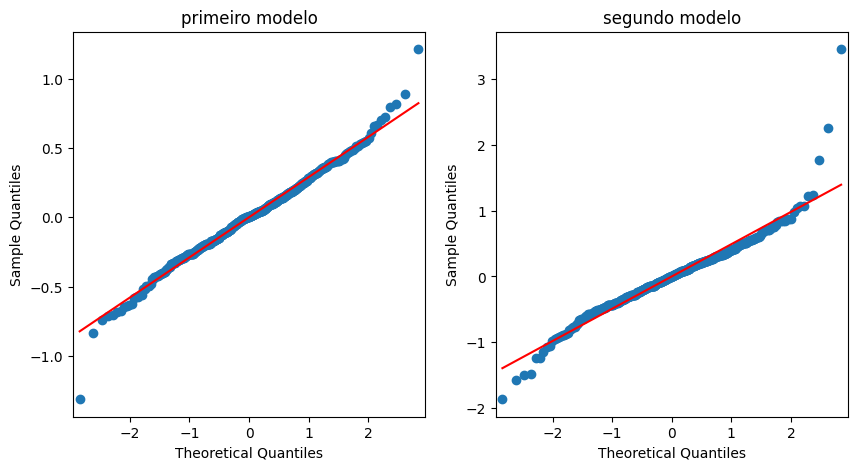

In [ ]:
out_test = model.resid
out_test2 = new_model.resid

fig, axes = plt.subplots(1, 2, figsize=(10,5))
sm.qqplot(out_test,line='s', ax = axes[0])
axes[0].set_title('primeiro modelo')
sm.qqplot(out_test2,line='s', ax = axes[1])
axes[1].set_title('segundo modelo')
#plt.title('segundo modelo')

plt.show()

In [ ]:
pred1 = model.predict(X_test)
pred2 = new_model.predict(new_X_test)

rms1 = root_mean_squared_error(y_test, pred1)
rms2 = root_mean_squared_error(y_test, pred2)

print('RMSE com todas as variaveis:', rms1, '\nRMSE com variaveis escolhidas: ', rms2)

RMSE com todas as variaveis: 1.0504498350168308 
RMSE com variaveis escolhidas:  0.5461558091484939


###Sem outliers

In [60]:
data_mod = cleaned_data
data_mod.drop(data_mod[data_mod.nu_param_B > 3].index, inplace=True)

In [44]:
X = []
for vet in data_mod['vetor_media']:
  X.append(np.array(vet))

In [45]:
y = data_mod['nu_param_B']
add_list = [(y.min()*(-1))+1]*len(y)

y = y + add_list
y, _ = stats.boxcox(y)
y[:3]
#y = stats.boxcox(y)

array([5.92540876, 6.87960634, 4.38702233])

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [47]:
#adicionando b0
X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)

In [51]:
model = sm.OLS(y_train, X_train).fit()
pred = model.predict(X_test)

rms = root_mean_squared_error(y_test, pred)

print('RMSE com todas as variaveis:', rms)

RMSE com todas as variaveis: 4.048974956373059


In [52]:
print(model.summary(alpha = 0.05))

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.759
Model:                            OLS   Adj. R-squared:                  0.217
Method:                 Least Squares   F-statistic:                     1.399
Date:                Thu, 10 Apr 2025   Prob (F-statistic):             0.0137
Time:                        19:58:48   Log-Likelihood:                -652.64
No. Observations:                 434   AIC:                             1907.
Df Residuals:                     133   BIC:                             3133.
Df Model:                         300                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.3232      4.078      1.060      0.2

In [53]:
variables = [30, 39, 59, 60, 68, 76, 98, 129, 143, 170, 175, 179, 182, 210, 221, 224, 232, 288]

In [54]:
new_X = []
for i in range(len(X)):
  new_obs = []
  for index in variables:
    new_obs.append(float(X[i][int(index-1)]))
  new_X.append(new_obs)

In [55]:
new_X_train, new_X_test, new_y_train, new_y_test = train_test_split(new_X, y, test_size = 0.3, random_state = 42)

In [56]:
#adicionando b0
new_X_train = sm.add_constant(new_X_train)
new_X_test = sm.add_constant(new_X_test)

In [58]:
new_model = sm.OLS(new_y_train, new_X_train).fit()
pred = new_model.predict(new_X_test)

rms = root_mean_squared_error(new_y_test, pred)

print('RMSE com as variaveis escolhidas:', rms)

RMSE com as variaveis escolhidas: 2.4069374731749553


In [59]:
print(new_model.summary(alpha = 0.05))

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.188
Model:                            OLS   Adj. R-squared:                  0.152
Method:                 Least Squares   F-statistic:                     5.323
Date:                Thu, 10 Apr 2025   Prob (F-statistic):           3.52e-11
Time:                        20:09:52   Log-Likelihood:                -916.70
No. Observations:                 434   AIC:                             1871.
Df Residuals:                     415   BIC:                             1949.
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.5235      0.500     11.039      0.0

## Lasso


### Dataset completo

In [34]:
X = []
for vet in cleaned_data['vetor_media']:
  X.append(np.array(vet))

In [35]:
y = cleaned_data['nu_param_B']
add_list = [(y.min()*(-1))+1]*len(y)

y = y + add_list
y, _ = stats.boxcox(y)
y[:3]
#y = stats.boxcox(y)

array([2.1903812 , 2.3790215 , 1.84427966])

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [37]:
model_lasso = LassoCV(alphas = [0.0001, 0.001, 0.01, 0.1, 1, 10], random_state=0).fit(X_train, y_train)
pred_lasso = model_lasso.predict(X_test)
#model_lasso.fit(X_train, y_train)
print('melhor r2 score (treino):', model_lasso.score(X_train, y_train))
print('r2 score (teste):', model_lasso.score(X_test, y_test))
print('melhor alpha:', model_lasso.alpha_)
print('RMSE com o alpha escolhido:', root_mean_squared_error(y_test, pred_lasso))

melhor r2 score (treino): 0.2262980988876815
r2 score (teste): 0.09443079686034905
melhor alpha: 0.001
RMSE com o alpha escolhido: 0.49686422292608257


###Sem outliers

In [61]:
data_mod = cleaned_data
data_mod.drop(data_mod[data_mod.nu_param_B > 3].index, inplace=True)

In [62]:
X = []
for vet in data_mod['vetor_media']:
  X.append(np.array(vet))

In [63]:
y = data_mod['nu_param_B']
add_list = [(y.min()*(-1))+1]*len(y)

y = y + add_list
y, _ = stats.boxcox(y)
y[:3]
#y = stats.boxcox(y)

array([5.92540876, 6.87960634, 4.38702233])

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [65]:
model_lasso = LassoCV(alphas = [0.0001, 0.001, 0.01, 0.1, 1, 10], random_state=0).fit(X_train, y_train)
pred_lasso = model_lasso.predict(X_test)
#model_lasso.fit(X_train, y_train)
print('melhor r2 score (treino):', model_lasso.score(X_train, y_train))
print('r2 score (teste):', model_lasso.score(X_test, y_test))
print('melhor alpha:', model_lasso.alpha_)
print('RMSE com o alpha escolhido:', root_mean_squared_error(y_test, pred_lasso))

melhor r2 score (treino): 0.14278869322754884
r2 score (teste): 0.01267906921318207
melhor alpha: 0.01
RMSE com o alpha escolhido: 2.26804106529649


## BERT regressão

In [ ]:
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 15.1 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system 

In [ ]:
import os

In [ ]:
os.environ['CUDA_LAUNCH_BLOCKING'] = "1"

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score
from transformers import TrainingArguments, Trainer
from datasets import Dataset

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained('neuralmind/bert-base-portuguese-cased')
tokenizer = AutoTokenizer.from_pretrained('neuralmind/bert-base-portuguese-cased', do_lower_case=False)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at neuralmind/bert-base-portuguese-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/210k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
def compute_metrics_for_regression(eval_pred):
    logits, labels = eval_pred
    labels = labels.reshape(-1, 1)

    mse = mean_squared_error(labels, logits)
    r2 = r2_score(labels, logits)
    rmse = root_mean_squared_error(labels, logits)

    return {"mse": mse, "r2": r2}

In [ ]:
training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/MED-enem/BERT_reg",
    #learning_rate=LEARNING_RATE,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=8,
    num_train_epochs=10,
    evaluation_strategy="epoch",
    #save_strategy="epoch",
    #save_total_limit=2,
    metric_for_best_model="rmse",
    #load_best_model_at_end=True,
    #weight_decay=0.01,
    report_to='none'
)

/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [ ]:
full_data = cleaned_data[['enunciado_limpo', 'nu_param_B']].dropna()
full_data.head(3)

,enunciado_limpo,nu_param_B
0,adicionada aumentando aumentar básico calor co...,1.13773
1,alta animais aproximarem arame campo cerca cer...,1.45214
2,anticorpos após barriga baseia baço biomphalar...,0.58402


In [ ]:
len(full_data)

638

In [ ]:
x_train = full_data['enunciado_limpo'][:415]
y_train = full_data['nu_param_B'][:415]

x_val = full_data['enunciado_limpo'][416:575]
y_val = full_data['nu_param_B'][416:575]

x_test = full_data['enunciado_limpo'][576:]
y_test = full_data['nu_param_B'][576:]

In [ ]:
list_encoded = []
for row in range(x_train.shape[0]):
  texto = str(x_train.iloc[row])
  label = int(y_train.iloc[row])
  encode = tokenizer(texto, padding='max_length', truncation=True, max_length=512)
  encode['texto'] = texto
  encode['label'] = label
  list_encoded.append(encode)

In [ ]:
list_encoded_val = []
for row in range(x_train.shape[0]):
  texto = str(x_train.iloc[row])
  label = int(y_train.iloc[row])
  encode = tokenizer(texto, padding='max_length', truncation=True, max_length=512)
  encode['texto'] = texto
  encode['label'] = label
  list_encoded_val.append(encode)

In [ ]:
list_encoded_test = []
for row in range(x_train.shape[0]):
  texto = str(x_train.iloc[row])
  label = int(y_train.iloc[row])
  encode = tokenizer(texto, padding='max_length', truncation=True, max_length=512)
  encode['texto'] = texto
  encode['label'] = label
  list_encoded_test.append(encode)

In [ ]:
#transformando as listas em Dataset (formato aceito pelo modelo)
eval_dataset = Dataset.from_list(list_encoded_val)
train_dataset = Dataset.from_list(list_encoded)
test_dataset = Dataset.from_list(list_encoded_test)

In [ ]:
model.resize_token_embeddings(len(tokenizer))

Embedding(29794, 768, padding_idx=0)

In [ ]:
import torch

class RegressionTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs[0][:, 0]
        loss = torch.nn.functional.mse_loss(logits, labels)
        return (loss, outputs) if return_outputs else loss

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics_for_regression,
)

trainer.train()

RuntimeError: CUDA error: device-side assert triggered
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.
